<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=300807538" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import sys
import importlib

# 1. Nettoyage et téléchargement du nouveau pipeline
# Remplace par l'URL de ta branche où tu vas pousser le nouveau data_pipeline.py
GITHUB_RAW_URL = "https://raw.githubusercontent.com/wekt2k04/NeuroSight_AI/main/notebooks/data_pipeline.py"

print("📥 Mise à jour du pipeline NeuroSight...")
!wget -q -O data_pipeline.py {GITHUB_RAW_URL}

if '/kaggle/working' not in sys.path:
    sys.path.append('/kaggle/working')

# 2. Importation dynamique
try:
    import data_pipeline
    importlib.reload(data_pipeline)
    from data_pipeline import prepare_data, show_sample_batch, plot_class_distribution
    print("✅ Pipeline 'Feature Engineered' chargé avec succès.")
except Exception as e:
    print(f"❌ Erreur d'import : {e}")

📥 Mise à jour du pipeline NeuroSight...
✅ Pipeline 'Feature Engineered' chargé avec succès.


In [2]:
# --- CONFIGURATION DES CHEMINS ---
# Assure-toi que ces chemins correspondent à tes inputs Kaggle
CSV_PATH = '/kaggle/input/datasets/wilfriedtsetse04/mon-csv-officiel/oasis_cross-sectional-5708aa0a98d82080.xlsx'
IMAGES_DIR = '/kaggle/input/datasets/ninadaithal/imagesoasis/Data'

# --- CRÉATION DES LOADERS ---
# Note : on utilise la nouvelle fonction 'prepare_data'
train_loader, val_loader, classes = prepare_data(
    csv_path=CSV_PATH, 
    images_dir=IMAGES_DIR, 
    batch_size=32
)

# # --- AUDIT VISUEL ---
# print(f"\n🚀 Classes prêtes : {classes}")
# plot_class_distribution(train_loader, classes)
# show_sample_batch(train_loader, classes)

📖 1. Chargement des données cliniques et Imputation MICE...
   ✅ Imputation des valeurs manquantes terminée (MICE).
🔍 2. Scan du dossier d'images : /kaggle/input/datasets/ninadaithal/imagesoasis/Data
   ✅ 47580 images valides associées avec succès.

🛡️ 3. Application du Stratified Group Split (Validation: 20.0%)...
   📊 Patients uniques Train : 161
   📊 Patients uniques Val   : 39
   🚨 Chevauchement (Leakage): 0 patients (Doit être 0).
   ⚠️ ATTENTION : La classe 'Moderate' n'a pas pu être placée dans la validation (trop peu de patients).

⚖️ 4. Calcul des poids pour l'équilibrage des classes dans les batchs...
🚀 Pipeline prêt ! Les DataLoaders vont générer des lots sécurisés et stratifiés.


🖥️ Moteur d'entraînement amorcé sur : cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 137MB/s]



🚀 Lancement : PHASE 1 : WARM-UP (Tête Uniquement) (3 Époques)
----------------------------------------
Époque 01/03 | Temps: 221s | Train Loss: 1.0584 Acc: 0.5435 | Val Loss: 1.2719 Acc: 0.4072
Époque 02/03 | Temps: 166s | Train Loss: 0.9901 Acc: 0.5790 | Val Loss: 1.2508 Acc: 0.4215
Époque 03/03 | Temps: 158s | Train Loss: 0.9797 Acc: 0.5790 | Val Loss: 1.2964 Acc: 0.3868
✅ Phase terminée. Meilleure Accuracy de validation : 0.4215

🚀 Lancement : PHASE 2 : FINE-TUNING (Discriminative LR) (12 Époques)
----------------------------------------
Époque 01/12 | Temps: 205s | Train Loss: 0.7462 Acc: 0.6830 | Val Loss: 1.2316 Acc: 0.4835
Époque 02/12 | Temps: 211s | Train Loss: 0.5140 Acc: 0.7858 | Val Loss: 1.2276 Acc: 0.5264
Époque 03/12 | Temps: 210s | Train Loss: 0.3865 Acc: 0.8419 | Val Loss: 1.3448 Acc: 0.5554
Époque 04/12 | Temps: 209s | Train Loss: 0.3013 Acc: 0.8767 | Val Loss: 1.5185 Acc: 0.5683
Époque 05/12 | Temps: 209s | Train Loss: 0.2405 Acc: 0.9022 | Val Loss: 1.5431 Acc: 0.58

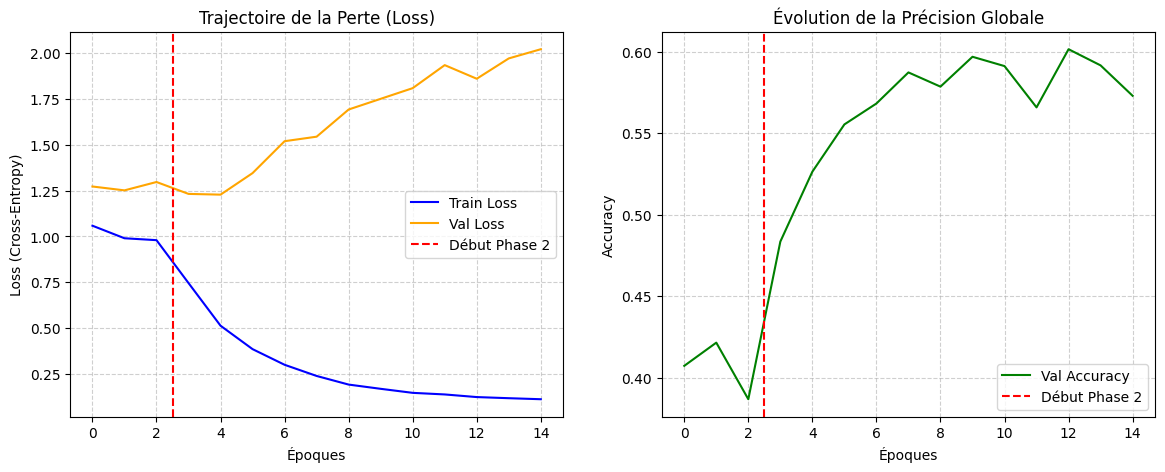

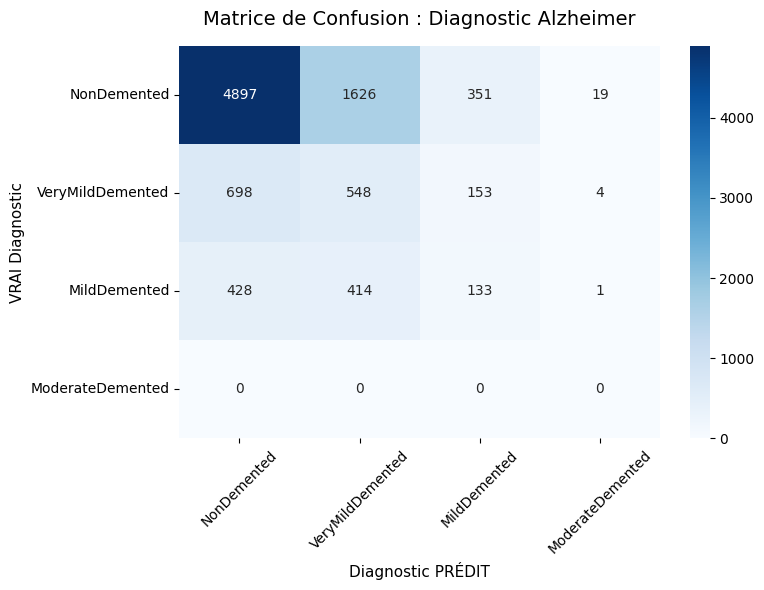

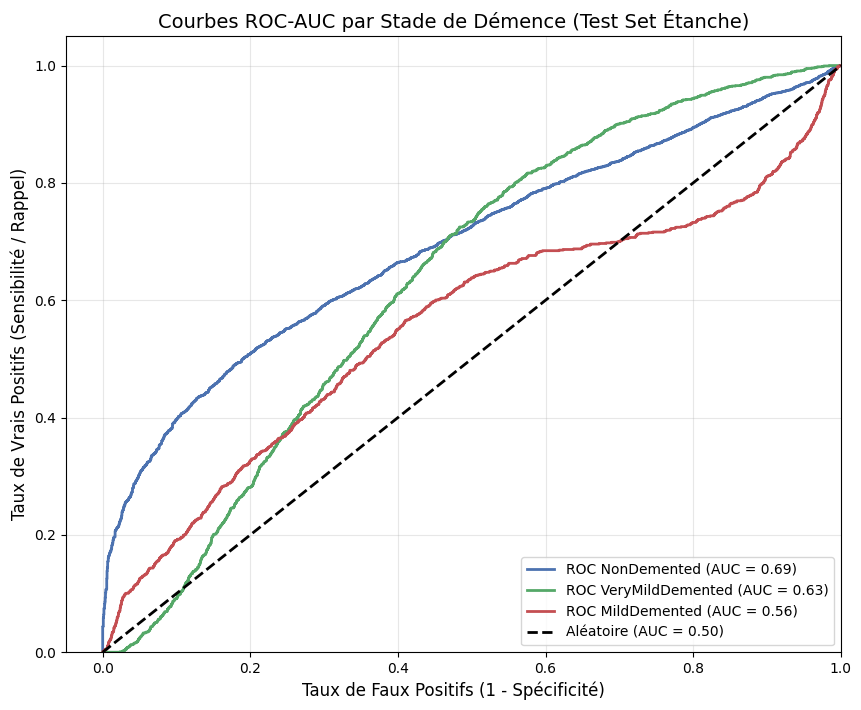

In [3]:
# ==========================================================
# CELLULE 3 : MOTEUR D'INFÉRENCE & FINE-TUNING EXPERT
# ==========================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Moteur d'entraînement amorcé sur : {device}")

# ----------------------------------------------------------
# 1. CONSTRUCTION DE L'ARCHITECTURE (EFFICIENTNET-B0)
# ----------------------------------------------------------
def build_neurosight_model(num_classes):
    # Chargement du Backbone pré-entraîné
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    num_ftrs = model.classifier[1].in_features
    
    # Remplacement de la tête de classification avec régularisation stochastique (Dropout)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(num_ftrs, num_classes)
    )
    return model.to(device)

model = build_neurosight_model(len(classes))

# ----------------------------------------------------------
# 2. LOGIQUE D'ENTRAÎNEMENT STRATÉGIQUE (PHASE 1 & 2)
# ----------------------------------------------------------
def train_model(model, train_loader, val_loader, num_epochs, optimizer, scheduler, phase_name=""):
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    print(f"\n🚀 Lancement : {phase_name} ({num_epochs} Époques)")
    print("-" * 40)
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                train_loss_val = epoch_loss
                train_acc_val = epoch_acc
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                # Le scheduler n'agit que sur la perte de validation
                scheduler.step(epoch_loss)
                
                # Sauvegarde des meilleurs poids (Early Stopping implicite)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

        time_elapsed = time.time() - start_time
        print(f"Époque {epoch+1:02d}/{num_epochs:02d} | Temps: {time_elapsed:.0f}s | "
              f"Train Loss: {train_loss_val:.4f} Acc: {train_acc_val:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} Acc: {history['val_acc'][-1]:.4f}")

    print(f"✅ Phase terminée. Meilleure Accuracy de validation : {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model, history

# --- EXÉCUTION DU PIPELINE D'ENTRAÎNEMENT ---

# PHASE 1 : WARM-UP (Échauffement de la tête)
# On gèle le corps (Feature Extractor) pour ne pas détruire les poids d'ImageNet
for param in model.features.parameters():
    param.requires_grad = False
    
# Optimiseur basique pour la tête
optimizer_warmup = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler_warmup = ReduceLROnPlateau(optimizer_warmup, mode='min', factor=0.5, patience=1)

model, hist_warmup = train_model(model, train_loader, val_loader, num_epochs=3, 
                                 optimizer=optimizer_warmup, scheduler=scheduler_warmup, phase_name="PHASE 1 : WARM-UP (Tête Uniquement)")

# PHASE 2 : FINE-TUNING EXPERT (Discriminative Learning Rates)
# On décongèle tout le réseau
for param in model.parameters():
    param.requires_grad = True

# 🧠 INJECTION EXPERTE : Taux d'apprentissage différents par couche
optimizer_ft = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-5},   # Le corps s'ajuste très délicatement
    {'params': model.classifier.parameters(), 'lr': 5e-4}  # La tête continue d'apprendre normalement
], weight_decay=1e-2)

scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.5, patience=2)

model, hist_ft = train_model(model, train_loader, val_loader, num_epochs=12, 
                             optimizer=optimizer_ft, scheduler=scheduler_ft, phase_name="PHASE 2 : FINE-TUNING (Discriminative LR)")

# Fusion des historiques pour les graphiques
full_history = {
    'train_loss': hist_warmup['train_loss'] + hist_ft['train_loss'],
    'val_loss': hist_warmup['val_loss'] + hist_ft['val_loss'],
    'val_acc': hist_warmup['val_acc'] + hist_ft['val_acc']
}


# ----------------------------------------------------------
# 3. ÉVALUATION CLINIQUE ET AUDIT STATISTIQUE
# ----------------------------------------------------------
def evaluate_and_plot(model, val_loader, class_names, history):
    model.eval()
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_probs = np.array(y_probs)
    
    print("\n" + "="*50)
    print("📊 RAPPORT DE PERFORMANCE MÉDICALE (F1 & RECALL)")
    print("="*50)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # --- Courbes d'Apprentissage ---
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='blue')
    plt.plot(history['val_loss'], label='Val Loss', color='orange')
    plt.axvline(x=2.5, color='red', linestyle='--', label='Début Phase 2') # Ligne de séparation
    plt.title('Trajectoire de la Perte (Loss)')
    plt.xlabel('Époques')
    plt.ylabel('Loss (Cross-Entropy)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.plot(history['val_acc'], label='Val Accuracy', color='green')
    plt.axvline(x=2.5, color='red', linestyle='--', label='Début Phase 2')
    plt.title('Évolution de la Précision Globale')
    plt.xlabel('Époques')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # --- Matrice de Confusion ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Matrice de Confusion : Diagnostic Alzheimer', fontsize=14, pad=15)
    plt.ylabel('VRAI Diagnostic', fontsize=11)
    plt.xlabel('Diagnostic PRÉDIT', fontsize=11)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # --- Courbes ROC-AUC Multiclasse ---
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    plt.figure(figsize=(10, 8))
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
    
    for i in range(len(class_names)):
        if np.sum(y_true_bin[:, i]) > 0: # Sécurité si classe absente du lot
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'ROC {class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Aléatoire (AUC = 0.50)')
    plt.xlim([-0.05, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs (1 - Spécificité)', fontsize=12)
    plt.ylabel('Taux de Vrais Positifs (Sensibilité / Rappel)', fontsize=12)
    plt.title('Courbes ROC-AUC par Stade de Démence (Test Set Étanche)', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Génération des résultats finaux
evaluate_and_plot(model, val_loader, classes, full_history)